 ## Best-Fit Line Concept

#### Definition
The best-fit line is the straight line that minimizes the total error between predictions and actual values across all training samples.

#### Goal: 
          Find the line that is "closest" to all the data points
          in the sense of minimizing prediction error

#### Error (Residual)
For each data point, the residual (error) is:
$$\text{Residual}_i = \hat{y}_i - y_i = (\text{prediction}) - (\text{actual})$$

Positive residual: prediction too high Negative residual: prediction too low

#### Finding the Best Fit
There are different ways to measure "best fit":

Least Squares (most common): Minimize sum of squared errors → leads to closed-form solution

Least Absolute Deviations: Minimize sum of absolute errors → more robust to outliers

Other losses: Huber loss, custom losses

For linear regression, we use Least Squares:
$$J(W, B) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$
 

The best W and B minimize this cost function.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [24]:
# data
x = np.array([600, 800, 1000, 1200, 1400,1600,1800]).reshape(-1,1)
y = np.array([180000, 200000, 230000, 255000, 280000, 305000, 330000])


In [25]:
# train model
model = LinearRegression()
model.fit(x,y)

# predict
y_pred = model.predict(x)

In [26]:
# calculate residuals
residuals = y-y_pred.flatten()

C:\Users\hp\AppData\Local\Temp\ipykernel_27676\1405796476.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


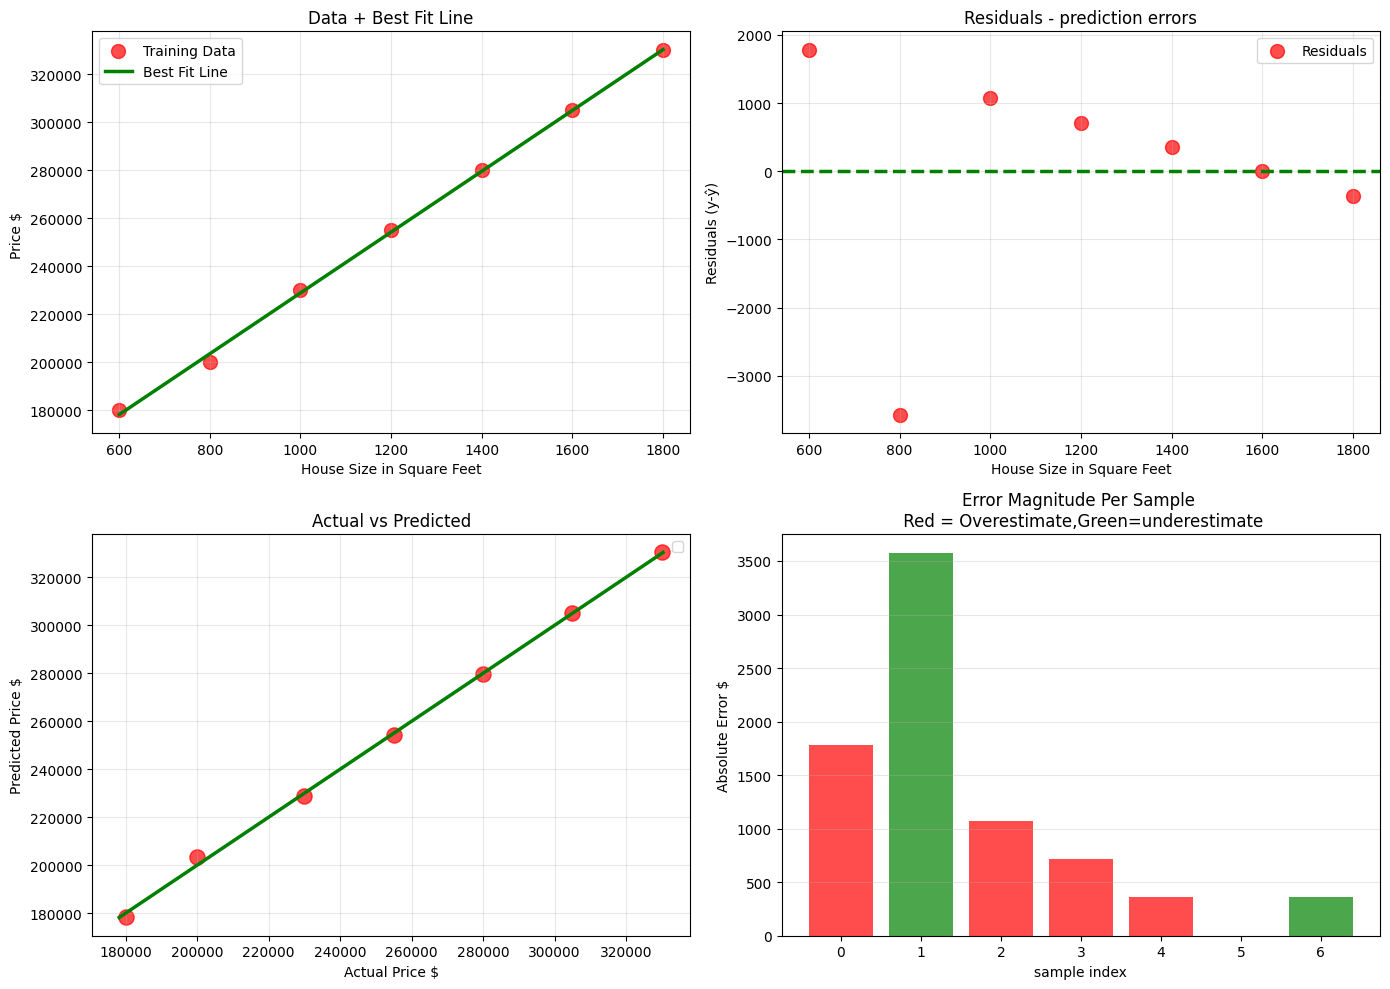

In [28]:
# Create comprehensive visualization
fig, axes = plt.subplots(2,2, figsize=(14,10))

# Plot 1: Data + Best-fit line
ax = axes[0,0]
ax.scatter(x,y, marker = 'o', c='r', s = 100, alpha =0.7, label = "Training Data")
ax.plot(x,y_pred, linewidth = 2.5, c='g', label = "Best Fit Line")
ax.set_xlabel("House Size in Square Feet")
ax.set_ylabel("Price $ ")
ax.set_title("Data + Best Fit Line")
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Residuals (errors)
ax = axes[0, 1]
ax.scatter(x,residuals, marker = 'o', c='r', s = 100, alpha=0.7, label = "Residuals")
ax.axhline(0, c='g',linestyle='--', linewidth = 2.5)
ax.set_xlabel("House Size in Square Feet")
ax.set_ylabel("Residuals (y-ŷ)")
ax.set_title("Residuals - prediction errors")
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Predictions vs Actual
ax = axes[1,0]
ax.scatter(y, y_pred, s=120, alpha=0.7, c = 'r')
# perfect predictions would be on the diagonal
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], c='g', linewidth = 2.5)
ax.set_xlabel("Actual Price $")
ax.set_ylabel("Predicted Price $")
ax.set_title("Actual vs Predicted")
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: Residuals with error bars
ax = axes[1,1]
colors = ['red' if r >0 else 'green' for r in residuals]
ax.bar(range(len(x)), np.abs(residuals),color = colors, alpha =0.7)
ax.set_xlabel("sample index")
ax.set_ylabel("Absolute Error $")
ax.set_title("Error Magnitude Per Sample \n Red = Overestimate,Green=underestimate")
ax.grid(True, alpha=0.3, axis = 'y')

plt.tight_layout()
plt.show()
